# Train Shared Bidirectional Arabizi/Arabic Transformer

This notebook trains a one-checkpoint bidirectional baseline so the project can show that a direct shared model was tried. It follows the same experiment shape as the other training notebooks: Google Drive/local path setup, data preparation, model architecture, validation, saved checkpoints, saved metrics, error analysis, top-k candidate evaluation, and paper-ready charts.

The model uses source-side direction tokens:

- `<TO_ARABIC>`: `arabizi -> arabic_stripped`
- `<TO_ARABIZI>`: `arabic_stripped -> arabizi`

In [ ]:
from __future__ import annotations

import csv
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

try:
    from IPython.display import display
except Exception:
    display = print

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

## Google Drive / Local Paths

In [ ]:
IN_COLAB = False
try:
    import google.colab  # type: ignore
    from google.colab import drive  # type: ignore

    IN_COLAB = True
except Exception:
    IN_COLAB = False

NOTEBOOK_STEM = "train_shared_bidirectional"

if IN_COLAB:
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/arabizi")
    DATA_FILE = PROJECT_ROOT / "maknuune-v1.0.1_cleaned.csv"
    RESULTS_DIR = PROJECT_ROOT / f"{NOTEBOOK_STEM}_files"
else:
    cwd = Path.cwd().resolve()
    if cwd.name == NOTEBOOK_STEM:
        PROJECT_ROOT = cwd.parents[1]
    else:
        PROJECT_ROOT = cwd
    DATA_FILE = PROJECT_ROOT / "working_files" / "data" / "maknuune-v1.0.1_cleaned.csv"
    RESULTS_DIR = PROJECT_ROOT / "working_files" / NOTEBOOK_STEM / f"{NOTEBOOK_STEM}_files"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}.pt"
BEST_MODEL_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_best.pt"
CHECKPOINT_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_checkpoint.pt"
METRICS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_metrics.csv"
LENGTH_METRICS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_metrics_by_length.csv"
ERROR_DETAIL_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_error_analysis_details.csv"
ERROR_BY_LENGTH_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_error_analysis_by_length.csv"
TOPK_PREDICTIONS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_predictions_softmax_90.csv"
TOPK_METRICS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_top_k_metrics.csv"
TOPK_BY_LENGTH_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_top_k_metrics_by_length.csv"
PREVIEW_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_prediction_preview.csv"
PROGRESS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_progress.csv"
REPORT_METRICS_JSON = RESULTS_DIR / "shared_bidirectional_metrics.json"

print("Data file:", DATA_FILE)
print("Results directory:", RESULTS_DIR)
print("Report metrics JSON:", REPORT_METRICS_JSON)

Mounted at /content/drive
Data file: /content/drive/MyDrive/arabizi/maknuune-v1.0.1_cleaned.csv
Results directory: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files
Report metrics JSON: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/shared_bidirectional_metrics.json


## Configuration

In [ ]:
PAD = "<PAD>"
BOS = "<BOS>"
EOS = "<EOS>"
UNK = "<UNK>"
TO_ARABIC = "<TO_ARABIC>"
TO_ARABIZI = "<TO_ARABIZI>"


@dataclass
class Config:
    d_model: int = 192
    nhead: int = 8
    num_encoder_layers: int = 3
    num_decoder_layers: int = 3
    dim_feedforward: int = 512
    dropout: float = 0.15
    batch_size: int = 128
    epochs: int = 100
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    seed: int = 42
    train_fraction: float = 0.80
    val_fraction: float = 0.10
    max_len_buffer: int = 4
    early_stopping_patience: int = 12
    periodic_save_every: int = 5
    softmax_sample_size: int = 1000
    softmax_probability_mass: float = 0.90
    softmax_max_candidates: int = 10


cfg = Config()
random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

asdict(cfg)

{'d_model': 192,
 'nhead': 8,
 'num_encoder_layers': 3,
 'num_decoder_layers': 3,
 'dim_feedforward': 512,
 'dropout': 0.15,
 'batch_size': 128,
 'epochs': 100,
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'seed': 42,
 'train_fraction': 0.8,
 'val_fraction': 0.1,
 'max_len_buffer': 4,
 'early_stopping_patience': 12,
 'periodic_save_every': 5,
 'softmax_sample_size': 1000,
 'softmax_probability_mass': 0.9,
 'softmax_max_candidates': 10}

## Data Preparation

In [ ]:
def clean(value: str, lowercase: bool = False) -> str:
    text = " ".join(("" if value is None else str(value)).split())
    return text.lower() if lowercase else text


def read_examples(path: Path) -> list[dict]:
    examples = []
    with path.open(newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row_id, row in enumerate(reader):
            arabizi = clean(row.get("arabizi", ""), lowercase=True)
            arabic = clean(row.get("arabic_stripped", ""))
            if not arabizi or not arabic:
                continue
            examples.append({
                "row_id": row_id,
                "direction": "arabizi_to_arabic",
                "src_text": arabizi,
                "tgt_text": arabic,
                "src_tokens": [TO_ARABIC, *list(arabizi)],
                "tgt_tokens": list(arabic),
            })
            examples.append({
                "row_id": row_id,
                "direction": "arabic_to_arabizi",
                "src_text": arabic,
                "tgt_text": arabizi,
                "src_tokens": [TO_ARABIZI, *list(arabic)],
                "tgt_tokens": list(arabizi),
            })
    return examples


examples = read_examples(DATA_FILE)
examples_df = pd.DataFrame([{k: v for k, v in ex.items() if k not in {"src_tokens", "tgt_tokens"}} for ex in examples])
print("Examples:", len(examples_df))
display(examples_df.groupby("direction").size().reset_index(name="rows"))
display(examples_df.head())

Examples: 72604


,direction,rows
0,arabic_to_arabizi,36302
1,arabizi_to_arabic,36302


,row_id,direction,src_text,tgt_text
0,0,arabizi_to_arabic,2abad,أبد
1,0,arabic_to_arabizi,أبد,2abad
2,1,arabizi_to_arabic,2ibre,إبرة
3,1,arabic_to_arabizi,إبرة,2ibre
4,2,arabizi_to_arabic,2ibar,إبر


In [ ]:
def split_examples(examples: list[dict], cfg: Config):
    grouped = {"arabizi_to_arabic": [], "arabic_to_arabizi": []}
    for ex in examples:
        grouped[ex["direction"]].append(ex)
    rng = random.Random(cfg.seed)
    train, val, test = [], [], []
    for rows in grouped.values():
        rng.shuffle(rows)
        train_end = int(len(rows) * cfg.train_fraction)
        val_end = train_end + int(len(rows) * cfg.val_fraction)
        train.extend(rows[:train_end])
        val.extend(rows[train_end:val_end])
        test.extend(rows[val_end:])
    rng.shuffle(train)
    rng.shuffle(val)
    rng.shuffle(test)
    return train, val, test


train_rows, val_rows, test_rows = split_examples(examples, cfg)
split_df = pd.DataFrame([
    {"split": "train", "rows": len(train_rows)},
    {"split": "val", "rows": len(val_rows)},
    {"split": "test", "rows": len(test_rows)},
])
display(split_df)

max_len = max(max(len(ex["src_tokens"]), len(ex["tgt_tokens"])) for ex in examples) + cfg.max_len_buffer
print("Max encoded length:", max_len)

,split,rows
0,train,58082
1,val,7260
2,test,7262


Max encoded length: 106


In [ ]:
def build_vocab(sequences: Iterable[list[str]], extra_tokens: list[str] | None = None):
    specials = [PAD, BOS, EOS, UNK]
    if extra_tokens:
        specials.extend(extra_tokens)
    tokens = sorted({tok for seq in sequences for tok in seq if tok not in specials})
    itos = specials + tokens
    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return stoi, itos


def encode(tokens: list[str], stoi: dict[str, int], max_len: int) -> list[int]:
    ids = [stoi[BOS], *[stoi.get(tok, stoi[UNK]) for tok in tokens], stoi[EOS]]
    ids = ids[:max_len]
    if ids[-1] != stoi[EOS]:
        ids[-1] = stoi[EOS]
    return ids + [stoi[PAD]] * (max_len - len(ids))


def decode(ids: list[int], itos: list[str]) -> str:
    tokens = []
    for idx in ids:
        tok = itos[int(idx)]
        if tok == EOS:
            break
        if tok in {PAD, BOS, TO_ARABIC, TO_ARABIZI}:
            continue
        tokens.append(tok)
    return "".join(tokens)


src_stoi, src_itos = build_vocab((ex["src_tokens"] for ex in train_rows), extra_tokens=[TO_ARABIC, TO_ARABIZI])
tgt_stoi, tgt_itos = build_vocab(ex["tgt_tokens"] for ex in train_rows)
print("Source vocab:", len(src_itos))
print("Target vocab:", len(tgt_itos))

Source vocab: 70
Target vocab: 68


## Dataset And Dataloaders

In [ ]:
class TransliterationDataset(Dataset):
    def __init__(self, rows: list[dict], src_stoi: dict[str, int], tgt_stoi: dict[str, int], max_len: int):
        self.rows = rows
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        src = torch.tensor(encode(row["src_tokens"], self.src_stoi, self.max_len), dtype=torch.long)
        tgt = torch.tensor(encode(row["tgt_tokens"], self.tgt_stoi, self.max_len), dtype=torch.long)
        return src, tgt, row["direction"], row["src_text"], row["tgt_text"]


def collate_batch(batch):
    src, tgt, direction, src_text, tgt_text = zip(*batch)
    return torch.stack(src), torch.stack(tgt), list(direction), list(src_text), list(tgt_text)


train_dataset = TransliterationDataset(train_rows, src_stoi, tgt_stoi, max_len)
val_dataset = TransliterationDataset(val_rows, src_stoi, tgt_stoi, max_len)
test_dataset = TransliterationDataset(test_rows, src_stoi, tgt_stoi, max_len)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_batch)

len(train_loader), len(val_loader), len(test_loader)

(454, 57, 57)

## Model Architecture

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, : x.size(1)])


class Seq2SeqTransformer(nn.Module):
    def __init__(self, cfg: Config, src_vocab_size: int, tgt_vocab_size: int, src_pad_idx: int, tgt_pad_idx: int, max_len: int):
        super().__init__()
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.d_model = cfg.d_model
        self.src_embedding = nn.Embedding(src_vocab_size, cfg.d_model, padding_idx=src_pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, cfg.d_model, padding_idx=tgt_pad_idx)
        self.positional_encoding = PositionalEncoding(cfg.d_model, cfg.dropout, max_len=max_len)
        self.transformer = nn.Transformer(
            d_model=cfg.d_model,
            nhead=cfg.nhead,
            num_encoder_layers=cfg.num_encoder_layers,
            num_decoder_layers=cfg.num_decoder_layers,
            dim_feedforward=cfg.dim_feedforward,
            dropout=cfg.dropout,
            batch_first=True,
            norm_first=True,
        )
        self.output_projection = nn.Linear(cfg.d_model, tgt_vocab_size)

    def forward(self, src: torch.Tensor, tgt_input: torch.Tensor) -> torch.Tensor:
        src_padding_mask = src.eq(self.src_pad_idx)
        tgt_padding_mask = tgt_input.eq(self.tgt_pad_idx)
        tgt_len = tgt_input.size(1)
        tgt_mask = torch.triu(torch.ones(tgt_len, tgt_len, device=tgt_input.device, dtype=torch.bool), diagonal=1)
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))
        hidden = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_projection(hidden)


model = Seq2SeqTransformer(cfg, len(src_itos), len(tgt_itos), src_stoi[PAD], tgt_stoi[PAD], max_len).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(cfg.epochs, 1))
criterion = nn.CrossEntropyLoss(ignore_index=tgt_stoi[PAD])

param_count = sum(p.numel() for p in model.parameters())
print(model)
print("Parameters:", f"{param_count:,}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


Seq2SeqTransformer(
  (src_embedding): Embedding(70, 192, padding_idx=0)
  (tgt_embedding): Embedding(68, 192, padding_idx=0)
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.15, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
          )
          (linear1): Linear(in_features=192, out_features=512, bias=True)
          (dropout): Dropout(p=0.15, inplace=False)
          (linear2): Linear(in_features=512, out_features=192, bias=True)
          (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.15, inplace=False)
          (dropout2): Dropout(p=0.15, inplace=False)
        )
      )
      (norm): L

## Metrics And Checkpoint Helpers

In [ ]:
def append_csv_row(path: Path, row: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    with path.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if not exists:
            writer.writeheader()
        writer.writerow(row)


model_config = asdict(cfg) | {
    "max_len": max_len,
    "src_vocab_size": len(src_itos),
    "tgt_vocab_size": len(tgt_itos),
    "src_pad_idx": src_stoi[PAD],
    "tgt_pad_idx": tgt_stoi[PAD],
    "train_rows": len(train_rows),
    "val_rows": len(val_rows),
    "test_rows": len(test_rows),
    "direction_tokens": [TO_ARABIC, TO_ARABIZI],
}


def bundle_payload(model: nn.Module, metrics_history: list[dict], final_metrics: dict | None = None) -> dict:
    return {
        "task_name": "shared_bidirectional",
        "source_col": "direction_token_plus_arabizi_or_arabic_stripped",
        "target_col": "arabic_stripped_or_arabizi",
        "model_state_dict": model.state_dict(),
        "model_config": model_config,
        "src_stoi": src_stoi,
        "src_itos": src_itos,
        "tgt_stoi": tgt_stoi,
        "tgt_itos": tgt_itos,
        "metrics_history": metrics_history,
        "final_metrics": final_metrics or {},
    }


def save_model_bundle(path: Path, model: nn.Module, metrics_history: list[dict], final_metrics: dict | None = None) -> None:
    torch.save(bundle_payload(model, metrics_history, final_metrics), path)


def save_checkpoint(epoch: int, best_val_sequence_accuracy: float, metrics_history: list[dict]) -> None:
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_sequence_accuracy": best_val_sequence_accuracy,
        "metrics_history": metrics_history,
        "model_config": model_config,
        "src_stoi": src_stoi,
        "src_itos": src_itos,
        "tgt_stoi": tgt_stoi,
        "tgt_itos": tgt_itos,
    }, CHECKPOINT_FILE)


def sequence_and_token_metrics(logits: torch.Tensor, targets: torch.Tensor, pad_idx: int):
    pred = logits.argmax(dim=-1)
    mask = targets.ne(pad_idx)
    token_correct = int((pred.eq(targets) & mask).sum().item())
    token_total = int(mask.sum().item())
    seq_correct = int(((pred.eq(targets) | ~mask).all(dim=1)).sum().item())
    return token_correct, token_total, seq_correct, pred

In [ ]:
def update_length_stats(stats: dict, directions: list[str], src_texts: list[str], tgt_texts: list[str], pred: torch.Tensor, tgt_out: torch.Tensor):
    mask = tgt_out.ne(tgt_stoi[PAD])
    row_correct = (pred.eq(tgt_out) | ~mask).all(dim=1).cpu().tolist()
    for direction, src_text, tgt_text, ok in zip(directions, src_texts, tgt_texts, row_correct):
        for length_type, text in [("source", src_text), ("target", tgt_text)]:
            bucket_start = (len(text) // 10) * 10
            bucket = f"{bucket_start}-{bucket_start + 9}"
            key = (direction, length_type, bucket)
            item = stats.setdefault(key, {"total": 0, "correct": 0})
            item["total"] += 1
            item["correct"] += int(ok)


def run_one_epoch(loader: DataLoader, training: bool, epoch: int = 0):
    model.train(training)
    total_loss = 0.0
    token_correct = token_total = seq_correct = seq_total = 0
    direction_counts: dict[str, list[int]] = {}
    length_stats: dict = {}
    for src, tgt, directions, src_texts, tgt_texts in loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)
        tgt_input = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        if training:
            optimizer.zero_grad(set_to_none=True)
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += float(loss.item()) * src.size(0)
        tc, tt, sc, pred = sequence_and_token_metrics(logits.detach(), tgt_out, tgt_stoi[PAD])
        token_correct += tc
        token_total += tt
        seq_correct += sc
        seq_total += src.size(0)
        mask = tgt_out.ne(tgt_stoi[PAD])
        row_correct = (pred.eq(tgt_out) | ~mask).all(dim=1).cpu().tolist()
        for direction, ok in zip(directions, row_correct):
            counts = direction_counts.setdefault(direction, [0, 0])
            counts[0] += int(ok)
            counts[1] += 1
        update_length_stats(length_stats, directions, src_texts, tgt_texts, pred, tgt_out)
    metrics = {
        "loss": total_loss / max(seq_total, 1),
        "token_accuracy": token_correct / max(token_total, 1),
        "sequence_accuracy": seq_correct / max(seq_total, 1),
    }
    for direction, (correct, total) in sorted(direction_counts.items()):
        metrics[f"{direction}_sequence_accuracy"] = correct / max(total, 1)
    return metrics, length_stats


def length_stats_to_df(length_stats: dict, split_name: str) -> pd.DataFrame:
    rows = []
    for (direction, length_type, length_bucket), stats in sorted(length_stats.items()):
        total = stats["total"]
        correct = stats["correct"]
        rows.append({
            "split": split_name,
            "direction": direction,
            "length_type": length_type,
            "length_bucket": length_bucket,
            "total": total,
            "correct": correct,
            "sequence_accuracy": correct / max(total, 1),
            "error_rate": 1 - (correct / max(total, 1)),
        })
    return pd.DataFrame(rows)

## Plotting Helpers

In [ ]:
def save_figure(fig, stem: str):
    png_path = RESULTS_DIR / f"{NOTEBOOK_STEM}_{stem}.png"
    pdf_path = RESULTS_DIR / f"{NOTEBOOK_STEM}_{stem}.pdf"
    fig.tight_layout()
    fig.savefig(png_path, dpi=180)
    fig.savefig(pdf_path)
    return png_path, pdf_path


def plot_training_figures(show: bool = True):
    if not METRICS_FILE.exists():
        return
    df = pd.read_csv(METRICS_FILE)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["epoch"], df["train_loss"], label="train loss")
    ax.plot(df["epoch"], df["val_loss"], label="val loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title("Shared bidirectional loss")
    ax.legend()
    save_figure(fig, "loss_error")
    if show:
        plt.show()
    else:
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["epoch"], 1 - df["train_sequence_accuracy"], label="train sequence error")
    ax.plot(df["epoch"], 1 - df["val_sequence_accuracy"], label="val sequence error")
    ax.set_xlabel("epoch")
    ax.set_ylabel("sequence error")
    ax.set_title("Shared bidirectional sequence error")
    ax.legend()
    save_figure(fig, "sequence_error")
    if show:
        plt.show()
    else:
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["epoch"], df["learning_rate"], label="learning rate")
    ax.set_xlabel("epoch")
    ax.set_ylabel("learning rate")
    ax.set_title("Shared bidirectional learning rate")
    ax.legend()
    save_figure(fig, "learning_rate")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_error_by_length(show: bool = True):
    if not ERROR_BY_LENGTH_FILE.exists():
        return
    df = pd.read_csv(ERROR_BY_LENGTH_FILE)
    for length_type in ["source", "target"]:
        plot_df = df[(df["length_type"] == length_type)].copy()
        if plot_df.empty:
            continue
        plot_df["bucket_start"] = plot_df["length_bucket"].str.extract(r"(\d+)").astype(int)
        plot_df = plot_df.sort_values(["direction", "bucket_start"])
        fig, ax = plt.subplots(figsize=(10, 5))
        for direction, group in plot_df.groupby("direction"):
            ax.plot(group["length_bucket"], group["error_rate"], marker="o", label=direction)
        ax.set_xlabel(f"{length_type} length bucket")
        ax.set_ylabel("error rate")
        ax.set_title(f"Shared bidirectional error by {length_type} length")
        ax.legend()
        save_figure(fig, f"error_by_{length_type}_length")
        if show:
            plt.show()
        else:
            plt.close(fig)


def plot_top_k(show: bool = True):
    if not TOPK_METRICS_FILE.exists():
        return
    df = pd.read_csv(TOPK_METRICS_FILE)
    fig, ax = plt.subplots(figsize=(7, 5))
    for direction, group in df.groupby("direction"):
        ax.plot(group["k"], group["top_k_accuracy"], marker="o", label=direction)
    ax.set_xlabel("k")
    ax.set_ylabel("top-k accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Shared bidirectional softmax-90 top-k accuracy")
    ax.legend()
    save_figure(fig, "top_k_accuracy")
    if show:
        plt.show()
    else:
        plt.close(fig)

## Train With Validation

In [ ]:
for path in [METRICS_FILE, PROGRESS_FILE]:
    if path.exists():
        path.unlink()

metrics_history: list[dict] = []
best_val_sequence_accuracy = -1.0
best_val_loss = float("inf")
epochs_without_loss_improvement = 0

for epoch in range(1, cfg.epochs + 1):
    train_metrics, _ = run_one_epoch(train_loader, training=True, epoch=epoch)
    with torch.no_grad():
        val_metrics, val_length_stats = run_one_epoch(val_loader, training=False, epoch=epoch)
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]
    metrics_row = {
        "epoch": epoch,
        "learning_rate": lr,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    metrics_history.append(metrics_row)
    append_csv_row(METRICS_FILE, metrics_row)
    append_csv_row(PROGRESS_FILE, {"epoch": epoch, "val_sequence_accuracy": val_metrics["sequence_accuracy"], "val_loss": val_metrics["loss"]})

    print(
        f"epoch {epoch:03d} | train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | val_seq_acc={val_metrics['sequence_accuracy']:.4f} | lr={lr:.6f}"
    )

    save_checkpoint(epoch, best_val_sequence_accuracy, metrics_history)
    if val_metrics["sequence_accuracy"] > best_val_sequence_accuracy:
        best_val_sequence_accuracy = val_metrics["sequence_accuracy"]
        save_model_bundle(BEST_MODEL_FILE, model, metrics_history, metrics_row)
        print("Saved new best model:", BEST_MODEL_FILE)

    if epoch % cfg.periodic_save_every == 0:
        save_model_bundle(RESULTS_DIR / f"{NOTEBOOK_STEM}_epoch_{epoch:03d}.pt", model, metrics_history, metrics_row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        epochs_without_loss_improvement = 0
    else:
        epochs_without_loss_improvement += 1

    plot_training_figures(show=False)

    if epochs_without_loss_improvement >= cfg.early_stopping_patience:
        print(f"Early stopping after {cfg.early_stopping_patience} epochs without validation-loss improvement.")
        break

save_model_bundle(MODEL_FILE, model, metrics_history, metrics_history[-1] if metrics_history else None)
print("Final model saved to:", MODEL_FILE)
print("Best model saved to:", BEST_MODEL_FILE)
print("Metrics saved to:", METRICS_FILE)

epoch 001 | train_loss=2.3379 | val_loss=1.4922 | val_seq_acc=0.0105 | lr=0.000300
Saved new best model: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_best.pt
epoch 002 | train_loss=1.4416 | val_loss=1.1158 | val_seq_acc=0.0554 | lr=0.000300
Saved new best model: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_best.pt
epoch 003 | train_loss=1.2243 | val_loss=0.9792 | val_seq_acc=0.0970 | lr=0.000299
Saved new best model: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_best.pt
epoch 004 | train_loss=1.1262 | val_loss=0.9042 | val_seq_acc=0.1204 | lr=0.000299
Saved new best model: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_best.pt
epoch 005 | train_loss=1.0633 | val_loss=0.8672 | val_seq_acc=0.1387 | lr=0.000298
Saved new best model: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bi

## Test Evaluation And Length Metrics

In [ ]:
if BEST_MODEL_FILE.exists():
    best_payload = torch.load(BEST_MODEL_FILE, map_location=DEVICE)
    model.load_state_dict(best_payload["model_state_dict"])

with torch.no_grad():
    test_metrics, test_length_stats = run_one_epoch(test_loader, training=False)

print("Test metrics:")
for key, value in test_metrics.items():
    print(f"  {key}: {value:.4f}")

length_df = length_stats_to_df(test_length_stats, "test")
length_df.to_csv(LENGTH_METRICS_FILE, index=False)
length_df.to_csv(ERROR_BY_LENGTH_FILE, index=False)

final_summary = {
    "task_name": "shared_bidirectional",
    "best_epoch": int(max(metrics_history, key=lambda r: r.get("val_sequence_accuracy", -1))["epoch"]) if metrics_history else 0,
    "best_val_sequence_accuracy": float(best_val_sequence_accuracy),
    "test_metrics": test_metrics,
    "config": model_config,
    "checkpoint_path": str(BEST_MODEL_FILE),
}
REPORT_METRICS_JSON.parent.mkdir(parents=True, exist_ok=True)
REPORT_METRICS_JSON.write_text(json.dumps(final_summary, ensure_ascii=False, indent=2), encoding="utf-8")
save_model_bundle(MODEL_FILE, model, metrics_history, final_summary)

print("Length metrics saved to:", LENGTH_METRICS_FILE)
print("Report metrics JSON saved to:", REPORT_METRICS_JSON)
display(pd.DataFrame([test_metrics]))
display(length_df.head())

Test metrics:
  loss: 0.3270
  token_accuracy: 0.8876
  sequence_accuracy: 0.5755
  arabic_to_arabizi_sequence_accuracy: 0.4508
  arabizi_to_arabic_sequence_accuracy: 0.7001
Length metrics saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_metrics_by_length.csv
Report metrics JSON saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/shared_bidirectional_metrics.json


,loss,token_accuracy,sequence_accuracy,arabic_to_arabizi_sequence_accuracy,arabizi_to_arabic_sequence_accuracy
0,0.326957,0.88762,0.575461,0.45084,0.700083


,split,direction,length_type,length_bucket,total,correct,sequence_accuracy,error_rate
0,test,arabic_to_arabizi,source,0-9,3409,1634,0.479319,0.520681
1,test,arabic_to_arabizi,source,10-19,189,3,0.015873,0.984127
2,test,arabic_to_arabizi,source,20-29,24,0,0.000000,1.000000
3,test,arabic_to_arabizi,source,30-39,6,0,0.000000,1.000000
4,test,arabic_to_arabizi,source,40-49,2,0,0.000000,1.000000


## Greedy Prediction Preview And Error Detail

In [ ]:
@torch.no_grad()
def greedy_decode_one(src_tokens: list[str], max_decode_len: int | None = None) -> str:
    max_decode_len = max_decode_len or max_len
    model.eval()
    src = torch.tensor([encode(src_tokens, src_stoi, max_len)], dtype=torch.long, device=DEVICE)
    ys = torch.tensor([[tgt_stoi[BOS]]], dtype=torch.long, device=DEVICE)
    for _ in range(max_decode_len - 1):
        logits = model(src, ys)
        next_id = int(logits[:, -1, :].argmax(dim=-1).item())
        ys = torch.cat([ys, torch.tensor([[next_id]], dtype=torch.long, device=DEVICE)], dim=1)
        if next_id == tgt_stoi[EOS]:
            break
    return decode(ys[0].tolist(), tgt_itos)


detail_rows = []
for row in test_rows:
    pred_text = greedy_decode_one(row["src_tokens"])
    detail_rows.append({
        "direction": row["direction"],
        "source": row["src_text"],
        "target": row["tgt_text"],
        "prediction": pred_text,
        "exact_match": pred_text == row["tgt_text"],
        "source_length": len(row["src_text"]),
        "target_length": len(row["tgt_text"]),
    })

detail_df = pd.DataFrame(detail_rows)
detail_df.to_csv(ERROR_DETAIL_FILE, index=False)
detail_df.head(50).to_csv(PREVIEW_FILE, index=False)
print("Error detail saved to:", ERROR_DETAIL_FILE)
print("Prediction preview saved to:", PREVIEW_FILE)
display(detail_df.head(10))

Error detail saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_error_analysis_details.csv
Prediction preview saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_prediction_preview.csv


,direction,source,target,prediction,exact_match,source_length,target_length
0,arabic_to_arabizi,وصية,wasiyye,wasiye,False,4,7
1,arabic_to_arabizi,ينتزع,yintizi3,yintizi3,True,5,8
2,arabic_to_arabizi,انخفى,2inkhafa,2inkhafa,True,5,8
3,arabic_to_arabizi,مرتبان,martabaan,murtabaan,False,6,9
4,arabizi_to_arabic,faqqiq,فقق,فقق,True,6,3
5,arabic_to_arabizi,حابى,7aaba,7aaba,True,4,5
6,arabizi_to_arabic,mafluuj,مفلوج,مفلوج,True,7,5
7,arabic_to_arabizi,متحيز,muta7ayyiz,mit7azzi,False,5,10
8,arabic_to_arabizi,اجتهد,2ijtahid,2ijtahad,False,5,8
9,arabizi_to_arabic,ma7aabis,محابس,محابس,True,8,5


## Softmax-90 Top-K Candidate Evaluation

In [ ]:
@torch.no_grad()
def softmax_90_candidates(src_tokens: list[str], max_decode_len: int | None = None):
    max_decode_len = max_decode_len or max_len
    model.eval()
    src = torch.tensor([encode(src_tokens, src_stoi, max_len)], dtype=torch.long, device=DEVICE)
    beams = [([tgt_stoi[BOS]], 0.0)]
    for _ in range(max_decode_len - 1):
        next_beams = []
        finished = []
        for seq, score in beams:
            if seq[-1] == tgt_stoi[EOS]:
                finished.append((seq, score))
                continue
            ys = torch.tensor([seq], dtype=torch.long, device=DEVICE)
            probs = torch.softmax(model(src, ys)[:, -1, :], dim=-1).squeeze(0)
            sorted_probs, sorted_ids = torch.sort(probs, descending=True)
            mass = 0.0
            kept = 0
            for prob, idx in zip(sorted_probs.tolist(), sorted_ids.tolist()):
                next_beams.append((seq + [int(idx)], score + math.log(max(float(prob), 1e-12))))
                mass += float(prob)
                kept += 1
                if mass >= cfg.softmax_probability_mass or kept >= cfg.softmax_max_candidates:
                    break
        beams = sorted(finished + next_beams, key=lambda item: item[1], reverse=True)[: cfg.softmax_max_candidates]
        if all(seq[-1] == tgt_stoi[EOS] for seq, _ in beams):
            break
    seen = set()
    candidates = []
    for seq, score in sorted(beams, key=lambda item: item[1], reverse=True):
        text = decode(seq, tgt_itos)
        if text and text not in seen:
            seen.add(text)
            candidates.append((text, score))
    return candidates[: cfg.softmax_max_candidates]


sample_rows = test_rows[: min(cfg.softmax_sample_size, len(test_rows))]
prediction_rows = []
metric_detail_rows = []
for row in sample_rows:
    candidates = softmax_90_candidates(row["src_tokens"])
    candidate_texts = [text for text, _ in candidates]
    record = {
        "direction": row["direction"],
        "source": row["src_text"],
        "target": row["tgt_text"],
    }
    for idx in range(cfg.softmax_max_candidates):
        record[f"candidate_{idx + 1}"] = candidate_texts[idx] if idx < len(candidate_texts) else ""
    prediction_rows.append(record)
    for k in [1, 3, 5, 10]:
        metric_detail_rows.append({
            "direction": row["direction"],
            "k": k,
            "hit": row["tgt_text"] in candidate_texts[:k],
            "source_length_bucket": f"{(len(row['src_text']) // 10) * 10}-{(len(row['src_text']) // 10) * 10 + 9}",
            "target_length_bucket": f"{(len(row['tgt_text']) // 10) * 10}-{(len(row['tgt_text']) // 10) * 10 + 9}",
        })

topk_predictions_df = pd.DataFrame(prediction_rows)
topk_detail_df = pd.DataFrame(metric_detail_rows)
topk_metrics_df = topk_detail_df.groupby(["direction", "k"], as_index=False).agg(total=("hit", "size"), hits=("hit", "sum"))
topk_metrics_df["top_k_accuracy"] = topk_metrics_df["hits"] / topk_metrics_df["total"]

length_rows = []
for group_col, length_type in [("source_length_bucket", "source"), ("target_length_bucket", "target")]:
    grouped = topk_detail_df.groupby(["direction", "k", group_col], as_index=False).agg(total=("hit", "size"), hits=("hit", "sum"))
    grouped["top_k_accuracy"] = grouped["hits"] / grouped["total"]
    grouped["length_type"] = length_type
    grouped = grouped.rename(columns={group_col: "length_bucket"})
    length_rows.append(grouped)
topk_by_length_df = pd.concat(length_rows, ignore_index=True) if length_rows else pd.DataFrame()

topk_predictions_df.to_csv(TOPK_PREDICTIONS_FILE, index=False)
topk_metrics_df.to_csv(TOPK_METRICS_FILE, index=False)
topk_by_length_df.to_csv(TOPK_BY_LENGTH_FILE, index=False)

print("Softmax-90 predictions saved to:", TOPK_PREDICTIONS_FILE)
print("Top-k metrics saved to:", TOPK_METRICS_FILE)
print("Top-k metrics by length saved to:", TOPK_BY_LENGTH_FILE)
display(topk_metrics_df)

Softmax-90 predictions saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_predictions_softmax_90.csv
Top-k metrics saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_top_k_metrics.csv
Top-k metrics by length saved to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files/train_shared_bidirectional_top_k_metrics_by_length.csv


,direction,k,total,hits,top_k_accuracy
0,arabic_to_arabizi,1,527,246,0.466793
1,arabic_to_arabizi,3,527,372,0.705882
2,arabic_to_arabizi,5,527,405,0.768501
3,arabic_to_arabizi,10,527,420,0.796964
4,arabizi_to_arabic,1,473,357,0.754757
5,arabizi_to_arabic,3,473,411,0.868922
6,arabizi_to_arabic,5,473,418,0.883721
7,arabizi_to_arabic,10,473,422,0.892178


## Paper-Ready Plots

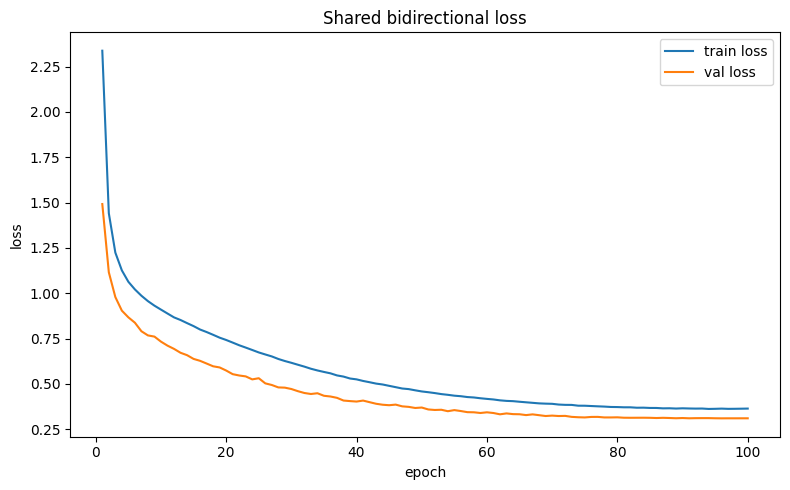

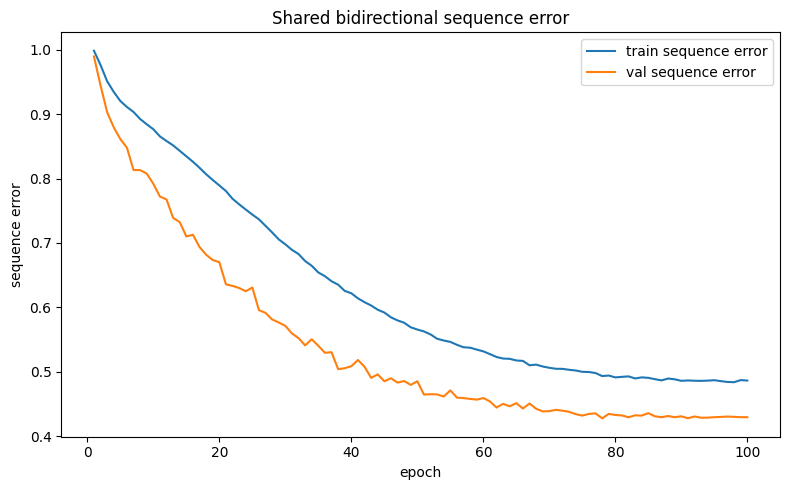

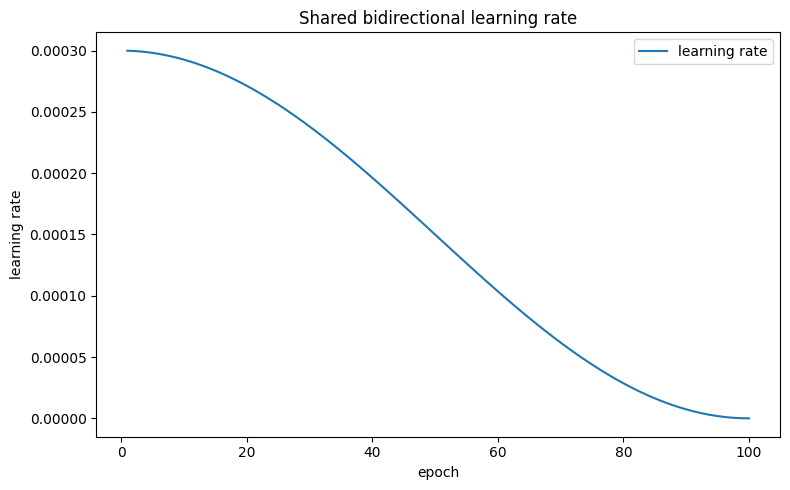

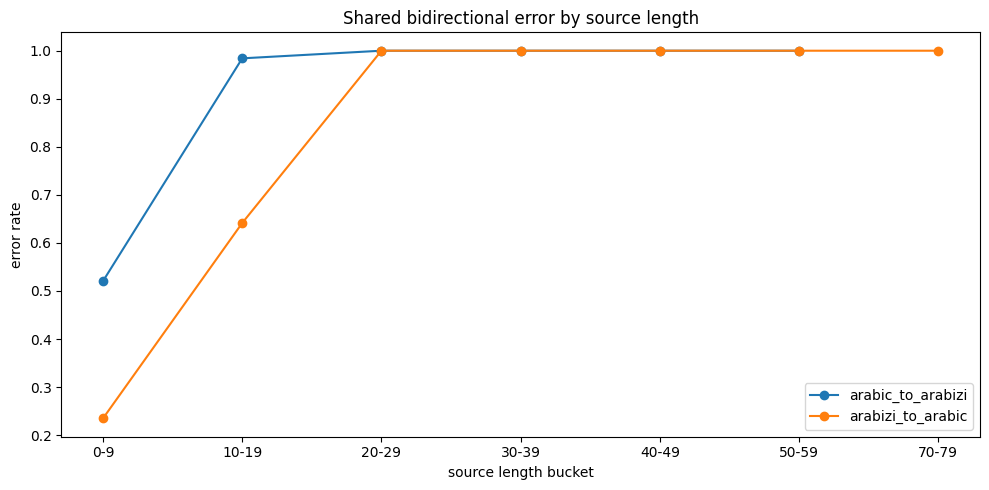

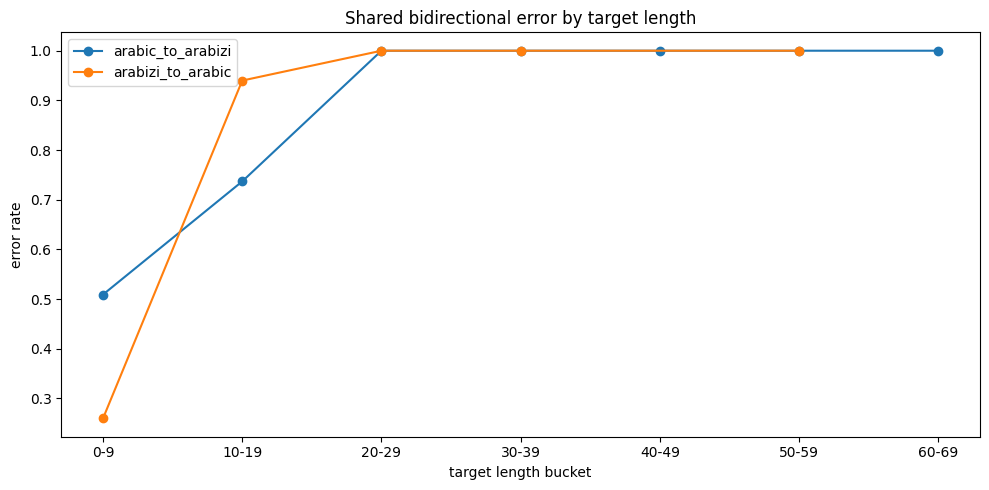

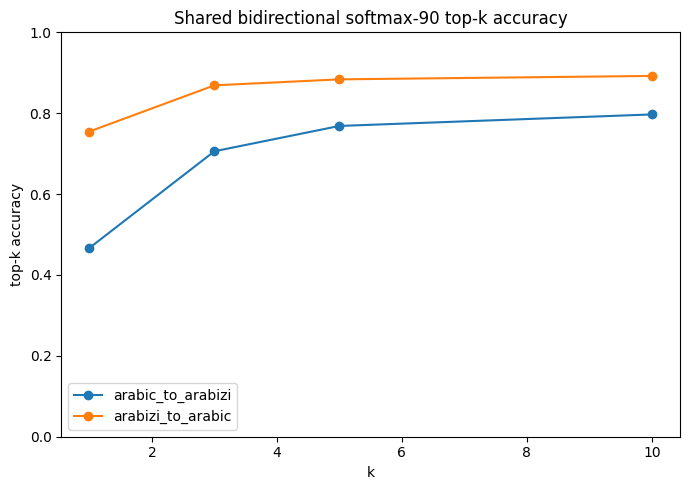

Saved plots to: /content/drive/MyDrive/arabizi/train_shared_bidirectional_files


In [ ]:
plot_training_figures(show=True)
plot_error_by_length(show=True)
plot_top_k(show=True)
print("Saved plots to:", RESULTS_DIR)

## Regenerate Final Report

In [1]:
import subprocess
import sys

report_script = PROJECT_ROOT / "scripts" / "generate_final_report.py"
if report_script.exists():
    subprocess.run([sys.executable, str(report_script)], check=True)
else:
    print("Report generator not found in this environment:", report_script)

NameError: name 'PROJECT_ROOT' is not defined